# Notebook B of line ratios from saved maps from the PZ cube

This is from the splitting up of ZZ-01-01-more-line-ratios.ipynb. It includes calculating the S III temperature and various ionization diagnostics with forbidden lines

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Path to the root of this repo

In [2]:
ROOT = Path.cwd().parent.parent

In [3]:
mapspath = ROOT / "data/n346-bow-lines/refined"

In [4]:
def get_image(lineid, combo="P-007", ext="SUM"):
    im = Image(str(mapspath / f"map-{lineid}-{combo}.fits"), ext=ext)
    im.data = im.data.astype(float)
    return im


def get_image_raw(lineid, variant="csub", channel="ABC"):
    p = ROOT / "data" / "n346-bow-lines" / f"maps-n346-PZ-2pass-{variant}-007"
    candidates = list(p.glob(f"**/*-{lineid}-{channel}.fits"))
    assert candidates
    imfile = candidates[0]
    im = Image(str(imfile))
    im.data = im.data.astype(float)
    return im

## Reddening law for SMC

In [5]:
rc = pn.RedCorr()
rc.R_V = 2.74
rc.FitzParams = [-4.96, 2.26, 0.39, 0.6, 4.6, 1.0]
rc.law = "F99"

## Calculate the [S III] temperature

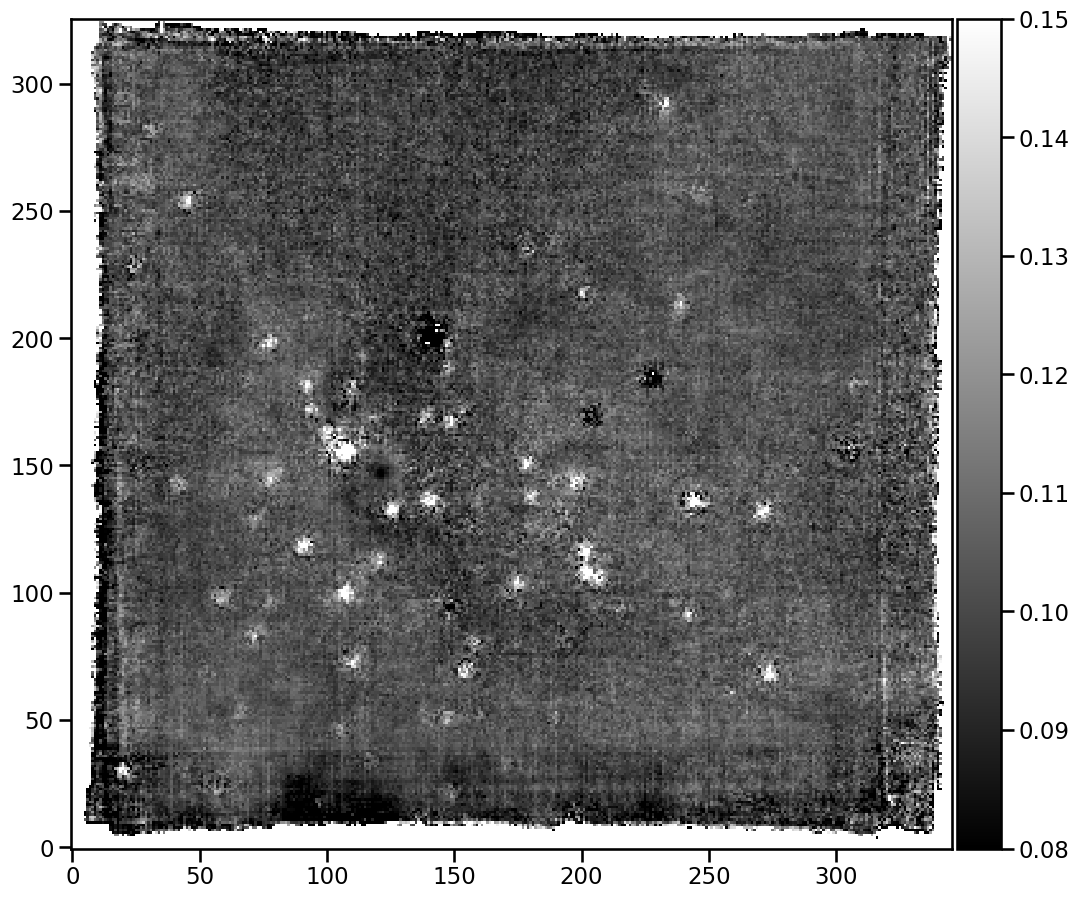

In [6]:


im6312 = get_image_raw("s-iii-6312-06")
im9069 = get_image_raw("s-iii-9068-90")
cont6312 = get_image_raw("s-iii-6312-06", variant="cont")

# The raw ratio:

fig, ax = plt.subplots(figsize=(12, 12))
(im6312 / im9069).plot(vmin=0.08, vmax=0.15, cmap="gray", colorbar="v")

# That looks more or less like the last time

imax = 15000
slope = 0.1
m = im9069.data < imax
m = m & (im9069.data > -100)
m = m & (im6312.data < slope * imax)
m = m & ~im9069.mask & ~im6312.mask
df = pd.DataFrame(
    {
        "9069": im9069.data[m].astype(float),
        "6312": im6312.data[m].astype(float),
    }
)

Text(0.5, 0.98, 'Correlation between [S III] 9069 and 6312 brightness')

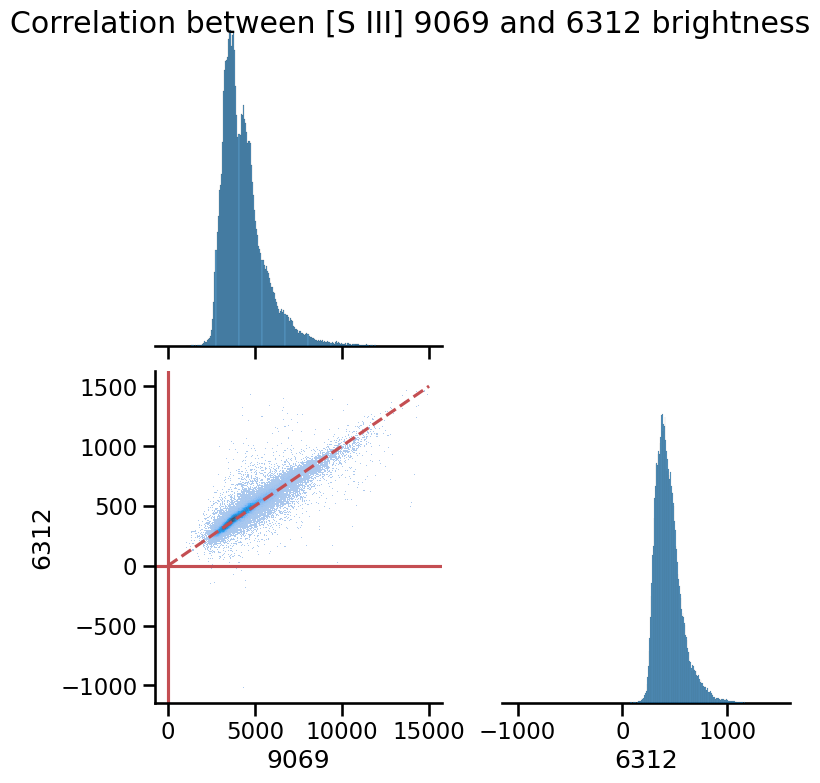

In [7]:
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)

g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.fig.suptitle("Correlation between [S III] 9069 and 6312 brightness")

Nothing needs to get added to anything.

In [8]:
imax = 5000
slope = 0.1
x = im9069.data
y = im6312.data
m = x < imax
m = m & (x > -100) & (y > -100)
m = m & (y < 1.2 * slope * imax)
m = m & ~im9069.mask & ~im6312.mask
df = pd.DataFrame(
    {
        "9069": x.data[m],
        "6312": y.data[m],
    }
)

Text(0.5, 0.98, 'ZOOMED Correlation between [S III] 9069 and 6312 brightness')

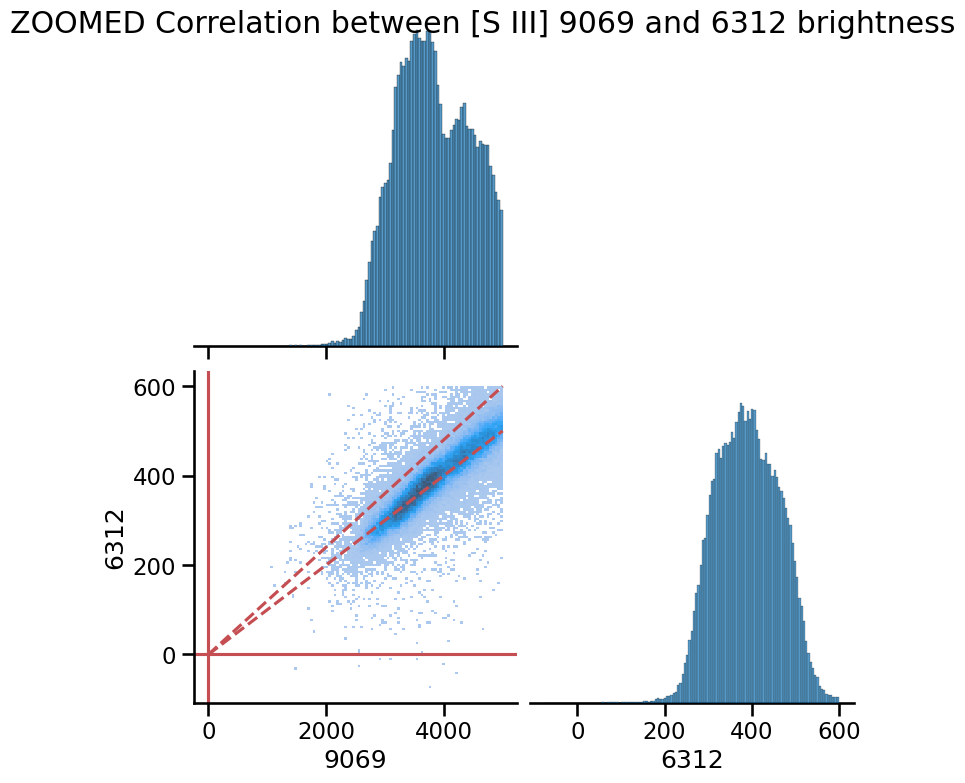

In [9]:
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)

g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.axes[1, 0].plot([0, imax], [0, 1.2 * slope * imax], "--", color="r")
g.fig.suptitle("ZOOMED Correlation between [S III] 9069 and 6312 brightness")

In [10]:
df.describe()

,9069,6312
count,79428.000000,79428.000000
mean,3824.137518,389.904971
std,614.034385,73.724752
min,1053.216553,-75.019531
25%,3354.666931,334.600403
50%,3782.454346,388.797180
75%,4326.563843,445.370155
max,4999.865234,599.507080


### Now we need to correct for reddening.

In [11]:
imEBV = Image(str(ROOT / "data/ngc346-ZZ-reddening-E_BV.fits"))

In [12]:
A9069 = rc.X(9069) * imEBV
im9069c = im9069.copy()
im9069c.data = im9069.data * 10 ** (0.4 * A9069.data)

In [13]:
A6312 = rc.X(6312) * imEBV
im6312c = im6312.copy()
im6312c.data = (im6312.data) * 10 ** (0.4 * A6312.data)

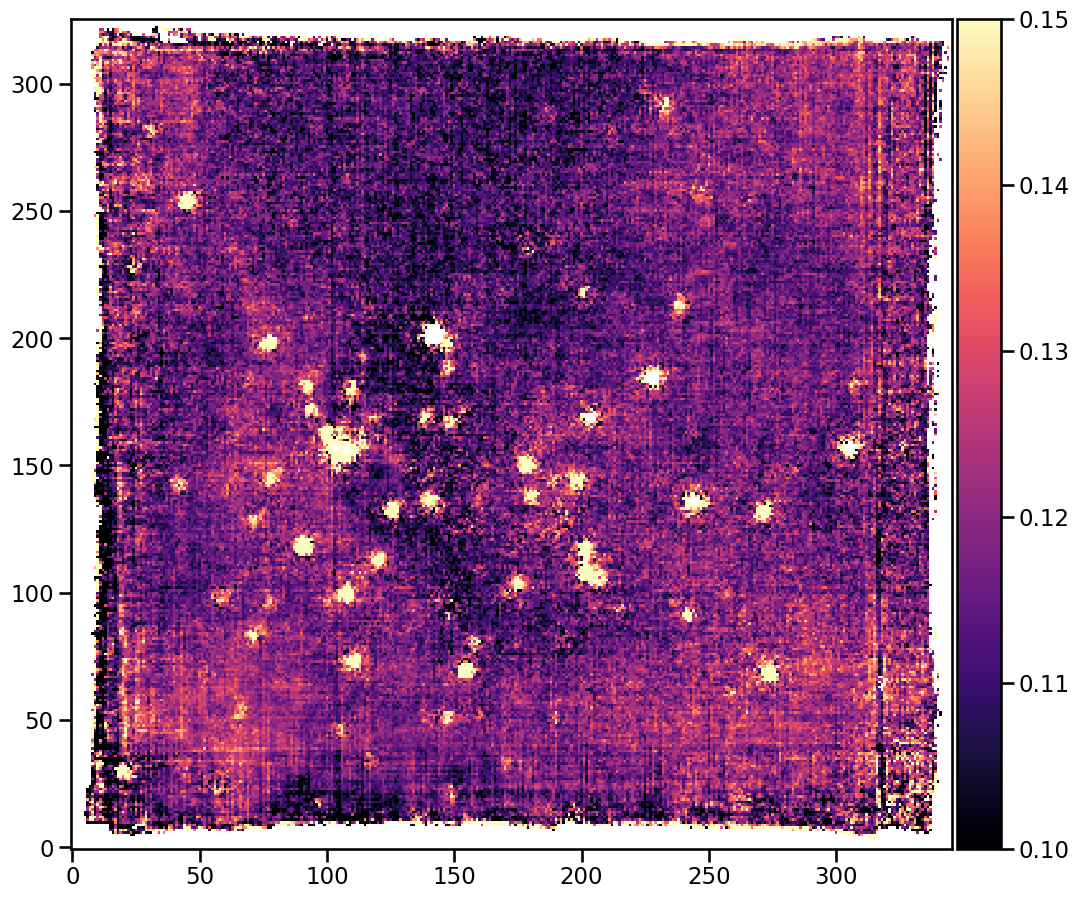

In [14]:
n = 1
fig, ax = plt.subplots(figsize=(12, 12))
(im6312c.rebin(n) / im9069c.rebin(n)).plot(
    vmin=0.1, vmax=0.15, cmap="magma", colorbar="v"
)

/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_72447/1931966129.py:2: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(im9069c.rebin(n).data)
/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_72447/1931966129.py:3: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(im6312c.rebin(n).data / im9069c.rebin(n).data)


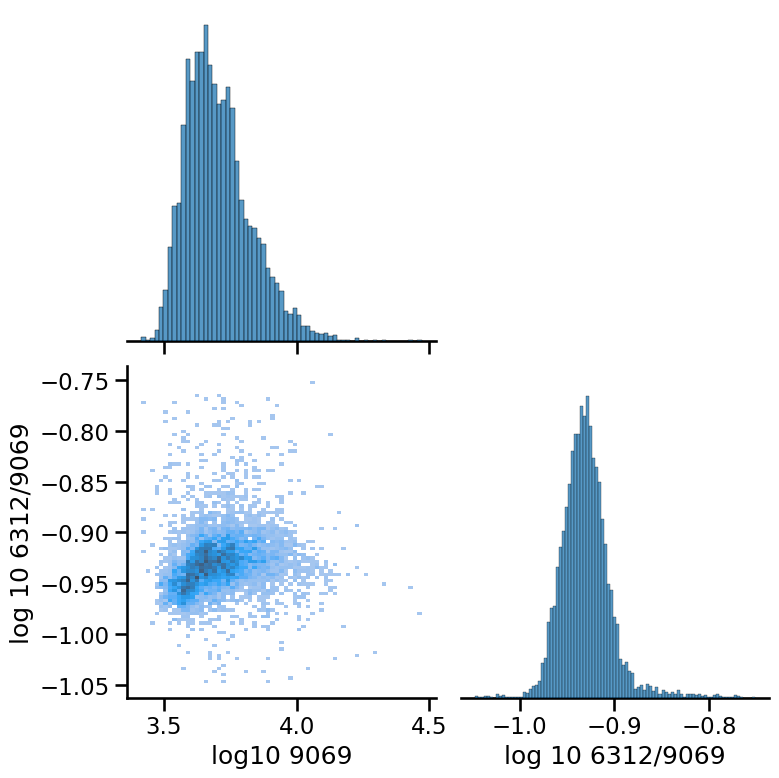

In [15]:
n = 4
x = np.log10(im9069c.rebin(n).data)
y = np.log10(im6312c.rebin(n).data / im9069c.rebin(n).data)
m = (x > 3.0) & (x < 4.5)
m = m & (y > -1.05) & (y < -0.75)
m = m & ~im9069c.rebin(n).mask & ~im6312c.rebin(n).mask
df = pd.DataFrame(
    {
        "log10 9069": x[m],
        "log 10 6312/9069": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)

This is totally different from what we got from the ESO cube.  This version is much more reliable, since with the other one we had no idea where the zeropoint was

Now, make a mask of EW(6312).  But first, we need to correct the zero point of the continuum.

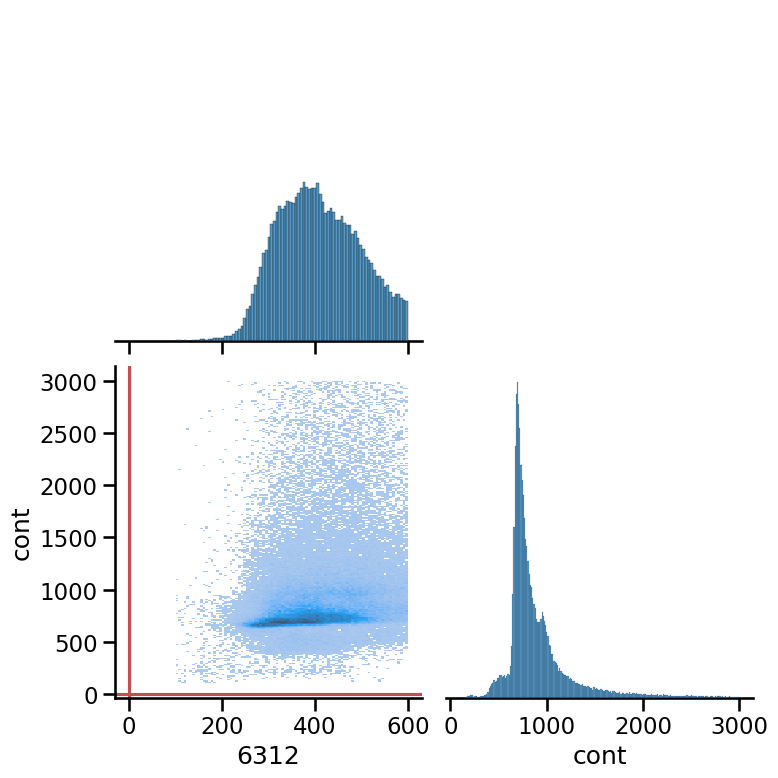

In [16]:
im6312_zero = 0.0
cont6312_zero = 0.0
imax = 600
x = im6312.data - im6312_zero
y = cont6312.data - cont6312_zero
m = x < imax
m = m & (x > 100)
m = m & (y < 3000) & (y > 100)
m = m & ~cont6312.mask & ~im6312.mask
df = pd.DataFrame(
    {
        "6312": x[m],
        "cont": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)

g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")

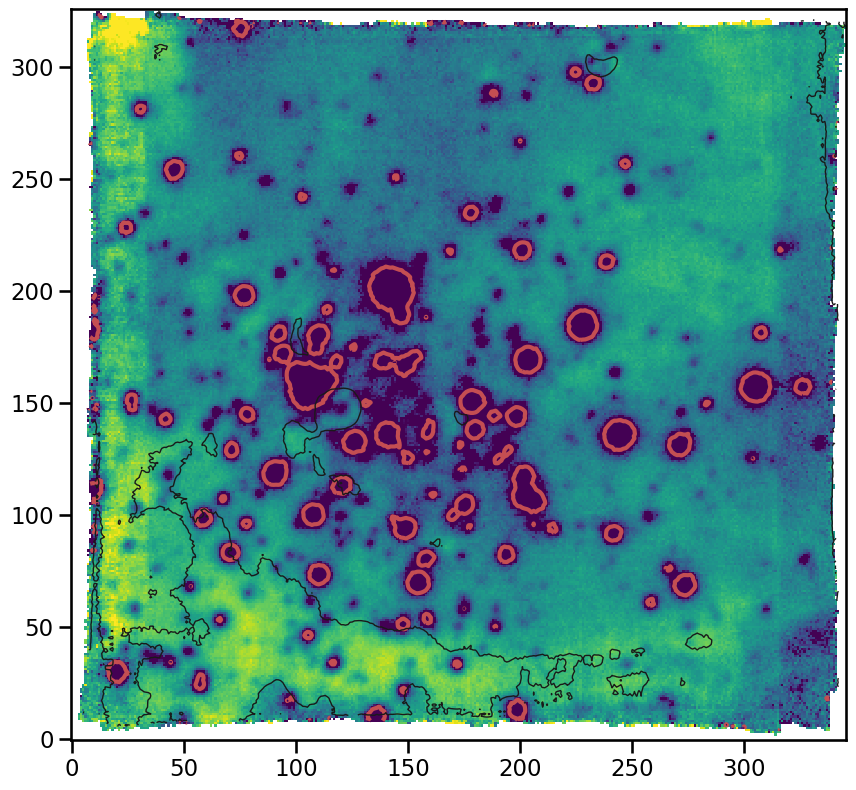

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))
ew6312 = 3 * 1.25 * (im6312 - im6312_zero) / (cont6312 - cont6312_zero)
ew6312.plot(vmin=1.0, vmax=5.0, scale="sqrt")
ax.contour(ew6312.data, levels=[0.5], colors="r", linewidths=3)
ax.contour(im9069.data, levels=[6000.0], colors="k", linewidths=1)

In [18]:
fixmask = (ew6312.data < 1.0) | (im9069.data < 3000.0)
fixmask = fixmask & (im6312c.data < 0.1 * im9069c.data)
fixmask = fixmask & (im6312c.data > 0.2 * im9069c.data)
iborder = 12
fixmask[:iborder, :] = True
fixmask[-iborder:, :] = True
fixmask[:, :iborder] = True
fixmask[:, -iborder:] = True

In [19]:
im6312c.mask = im6312c.mask | fixmask

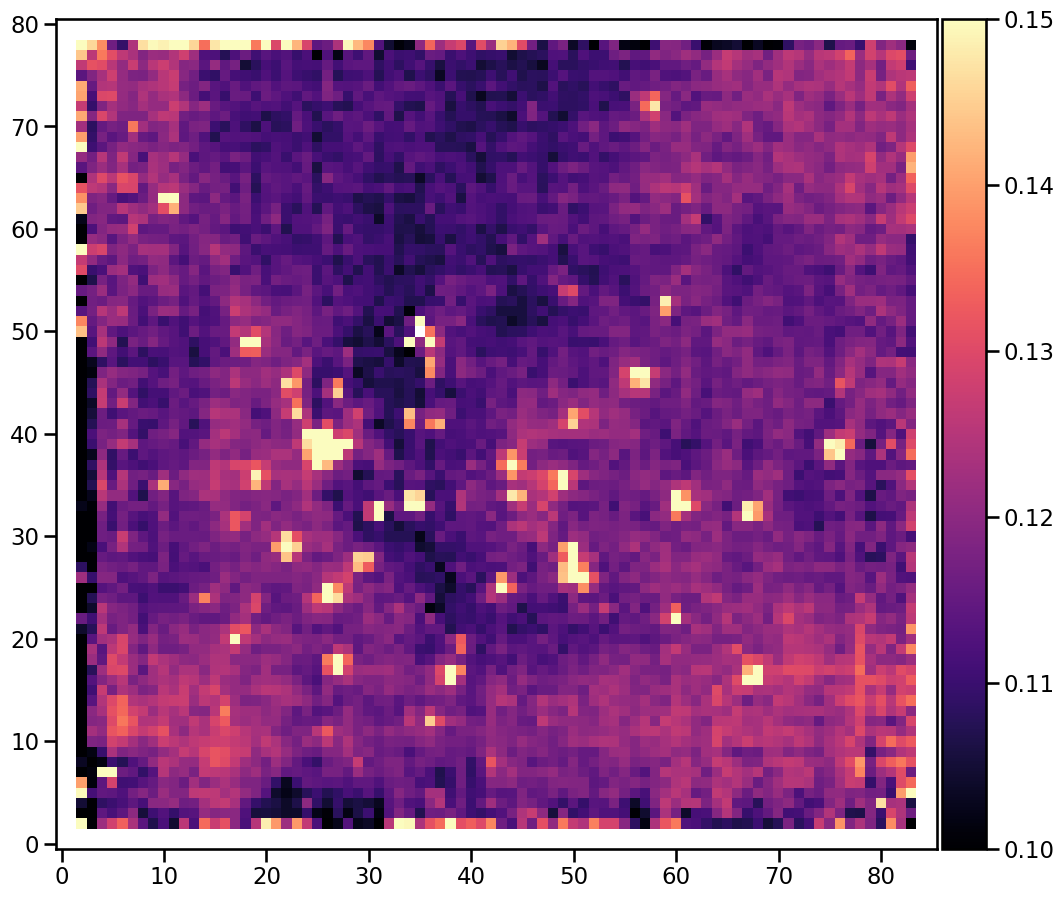

In [20]:
n = 4
fig, ax = plt.subplots(figsize=(12, 12))
(im6312c.rebin(n) / im9069c.rebin(n)).plot(
    vmin=0.1, vmax=0.15, cmap="magma", colorbar="v"
)

Honestly, this looks identical to the last one. So I do not know what I am even doing here.

/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_72447/1463797845.py:2: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(im9069c.rebin(n).data)
/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_72447/1463797845.py:3: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(im6312c.rebin(n).data / im9069c.rebin(n).data)


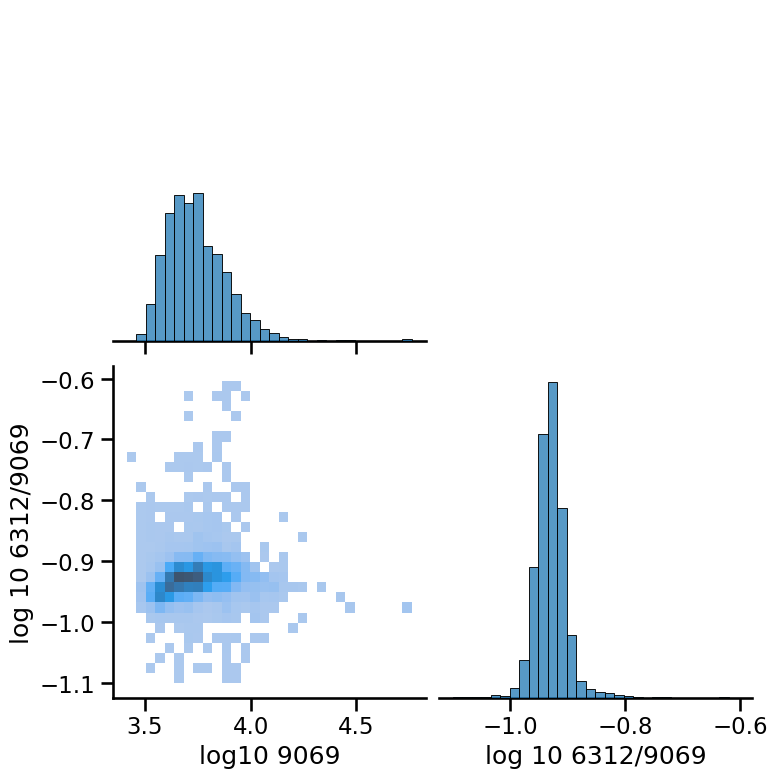

In [21]:
n = 4
x = np.log10(im9069c.rebin(n).data)
y = np.log10(im6312c.rebin(n).data / im9069c.rebin(n).data)
z = im9069c.rebin(n).data
m = (x > 2.5) & (x < 5.5)
m = m & (y > -1.1) & (y < -0.6)
m = m & ~im9069c.rebin(n).mask & ~im6312c.rebin(n).mask
df = pd.DataFrame(
    {
        "log10 9069": x[m],
        "log 10 6312/9069": y[m],
    }
)
kws = dict(weights=z[m], bins=30)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=kws,
    diag_kws=kws,
)

### Convert to actual temperatures with pyneb

In [22]:
s3 = pn.Atom("S", 3)

In [23]:
s3.getTemDen([0.1, 0.2], den=100.0, wave1=6312, wave2=9069)

array([12128.90515246, 19243.6434518 ])

In [24]:
r_s3_grid = np.linspace(0.05, 0.25, 201)
T_s3_grid = s3.getTemDen(r_s3_grid, den=100.0, wave1=6312, wave2=9069)

In [25]:
imT_siii = im6312c.clone(data_init=np.empty)
imT_siii.data[~fixmask] = np.interp(
    im6312c.data[~fixmask] / im9069c.data[~fixmask],
    r_s3_grid,
    T_s3_grid,
    left=np.nan,
    right=np.nan,
)
# imT_siii.mask = imT_siii.mask | fixmask
# imT_siii.data[imT_siii.mask] = np.nan

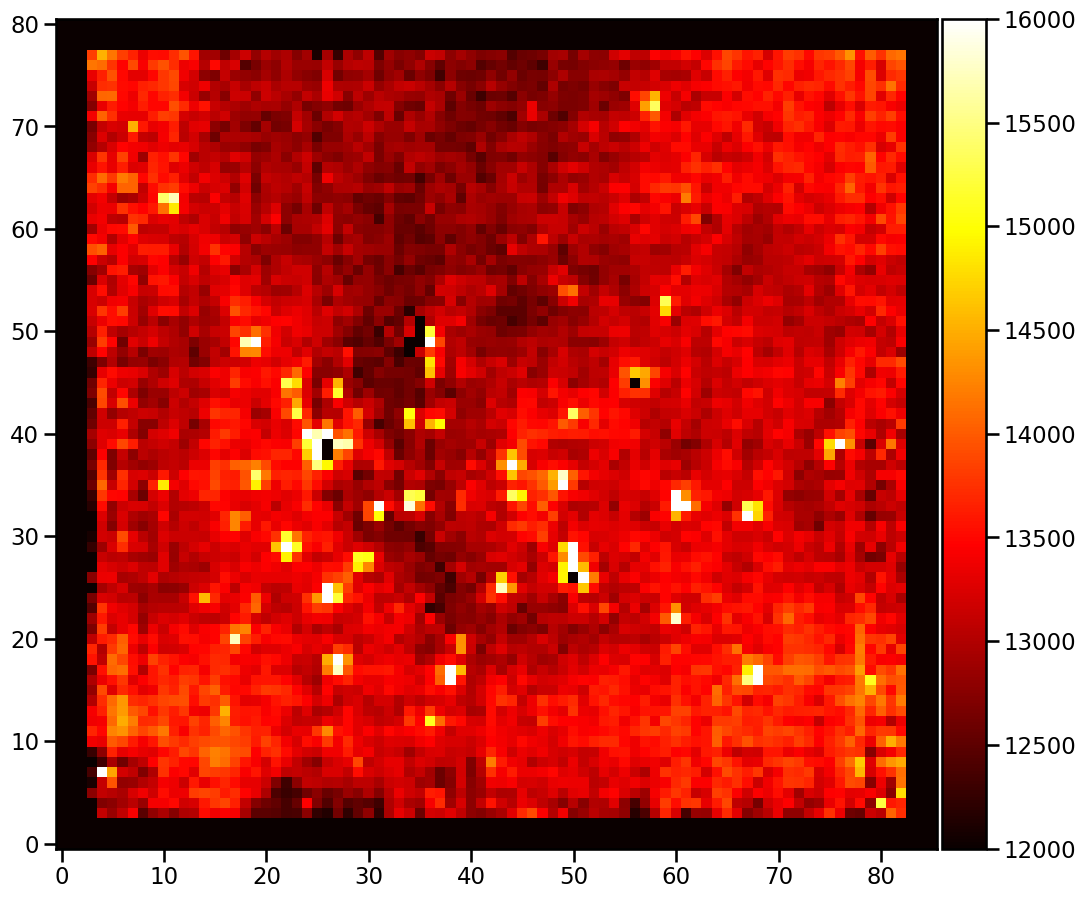

In [26]:
fig, ax = plt.subplots(figsize=(12, 12))
imT_siii.rebin(4).plot(colorbar="v", cmap="hot", vmin=12000, vmax=16000)

In [27]:
badpix = ~np.isfinite(imT_siii.data)
imT_siii.mask = imT_siii.mask | badpix

In [28]:
imT_siii.write(str(ROOT / "data/ngc346-ZZ-T-siii.fits"), savemask="nan")

The rather disappointing conclusion of this is that the [S III] temperatures do vary from about 13 to 16 kK, but they don't show anything special at the bow shock, being about 13.7 +/- 0.4 kK there. **Now slightly lower: see below**

If anything, the T is lower in the bow shock.

Average over whole FOV is 14.2 +/- 0.8 kK after smoothing to eliminate the noise contribution.  This implies $t^2 = 0.003$ in plane of sky, which is small.

#### Average over the bow shock box

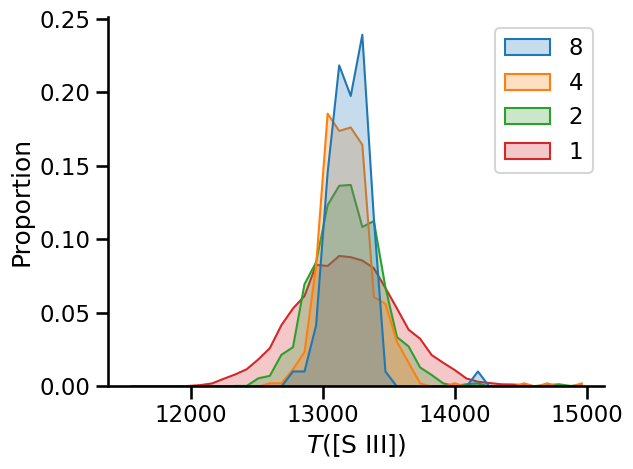

In [29]:
xslice, yslice = slice(230, 300), slice(144, 245)
def get_bow_T(n):
    imT_siii_bow = imT_siii[yslice, xslice].rebin(n)
    T_siii_bow = imT_siii_bow.data[~imT_siii_bow.mask]
    return T_siii_bow
xmin, xmax = 11500, 15000
binnings = [1, 2, 4, 8]
Tdict = {_n: get_bow_T(_n) for _n in binnings}
g = sns.histplot(
    Tdict, 
    bins=40, 
    binrange=[xmin, xmax], 
    stat="proportion", 
    common_norm=False, 
    multiple="layer",
    hue_order=binnings[::-1],
    element="poly",
).set_xlabel("$T$([S III])")
sns.despine()

In [30]:
[len(_) for _ in Tdict.values()]

[7067, 1750, 425, 96]

In [31]:
for _n, _T in Tdict.items():
    print(f"{_n}: {np.mean(_T)/1000:.2f} +/- {np.std(_T)/1000:.2f}")


1: 13.20 +/- 0.44
2: 13.20 +/- 0.31
4: 13.19 +/- 0.22
8: 13.19 +/- 0.16


So it looks like the 1 and 2 binnings are dominated by noise, while the 4 binning is showing real structure.  So, we can take the $T = 13.19 \pm 0.19$ kK.

## Calculate [O III]/[S III]

In [32]:
im5007 = get_image_raw("o-iii-5006-84")

Correct for extinction:

In [33]:
A5007 = rc.X(5007) * imEBV
im5007c = im5007.copy()
im5007c.data = im5007.data * 10 ** (0.4 * A5007.data)

In [34]:
np.nanmedian(imEBV[150:250, 200:300].data.data)

0.13737119734287262

In [35]:
median_EBV = np.nanmedian(imEBV[150:250, 200:300].data.data)
median_EBV

0.13737119734287262

In [36]:
im5007cc = im5007.copy()
im5007cc.data = im5007.data * 10 ** (0.4 * rc.X(5007) * median_EBV)
im9069cc = im9069.copy()
im9069cc.data = im9069.data * 10 ** (0.4 * rc.X(9069) * median_EBV)

Quick look:

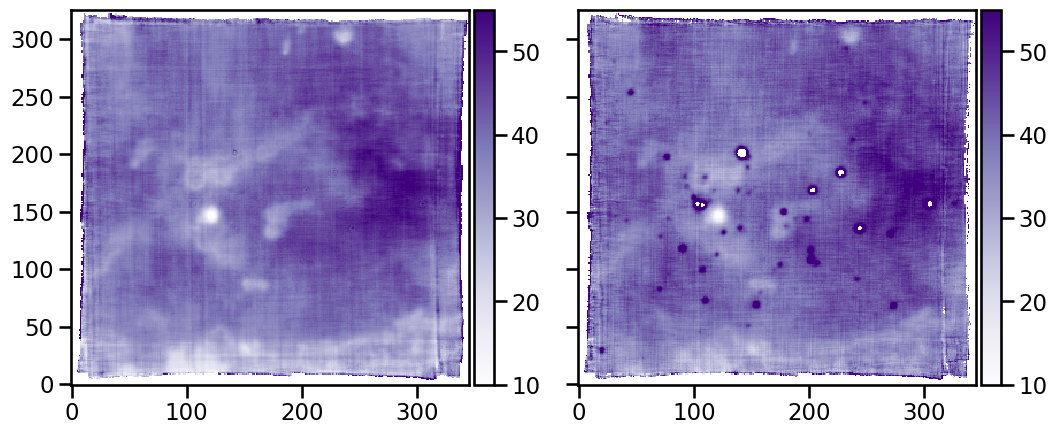

In [37]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
((im5007cc) / im9069cc).plot(
    vmin=10,
    vmax=55,
    colorbar="v",
    scale="linear",
    cmap="Purples",
    ax=axes[0],
)
((im5007c) / im9069c).plot(
    vmin=10,
    vmax=55,
    colorbar="v",
    scale="linear",
    cmap="Purples",
    ax=axes[1],
)

The left panel is with a median reddening. The right panel is with a pixel-by-pixel reddening but that fails at the position of stars.

Check zero points:

Text(0.5, 0.98, 'Correlation between [S III] 9069 and [O III] 5007 brightness')

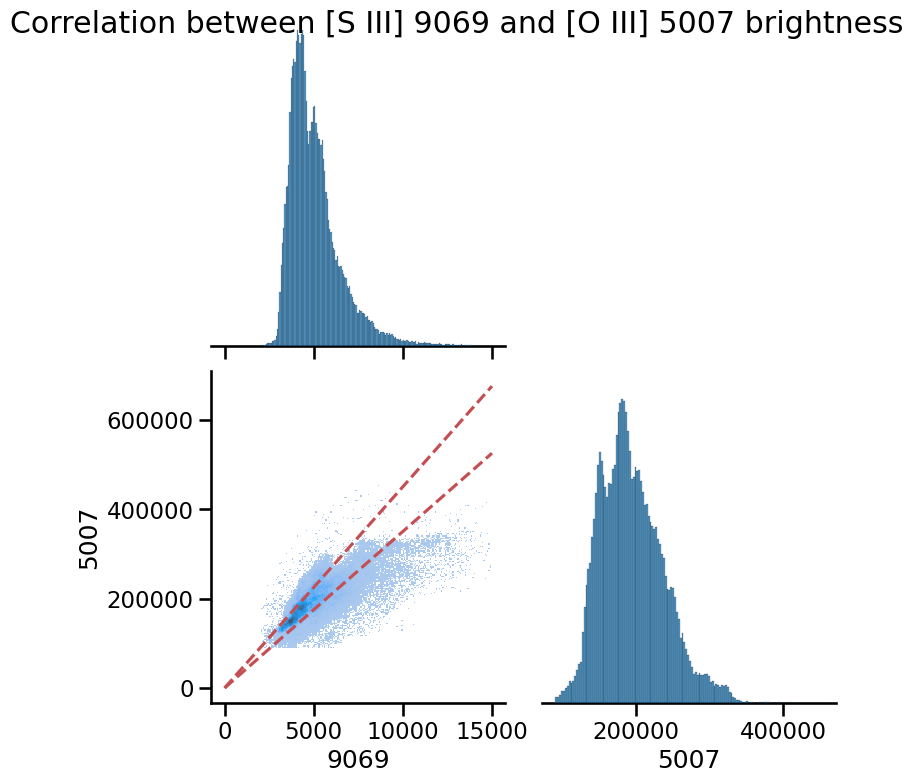

In [38]:
imax = 15000
imin = 2000
slope = 45
slope2 = 35
x = im9069cc.data
y = im5007cc.data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > slope * imin)
m = m & ~im9069c.mask & ~im5007c.mask
df = pd.DataFrame(
    {
        "9069": x[m],
        "5007": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
# g.axes[1, 0].axvline(0.0, color="r")
# g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.axes[1, 0].plot([0, imax], [0, slope2 * imax], "--", color="r")
g.fig.suptitle("Correlation between [S III] 9069 and [O III] 5007 brightness")

Text(0.5, 0.98, 'Correlation between [S III] 9069 and [O III] / [S III] ratio')

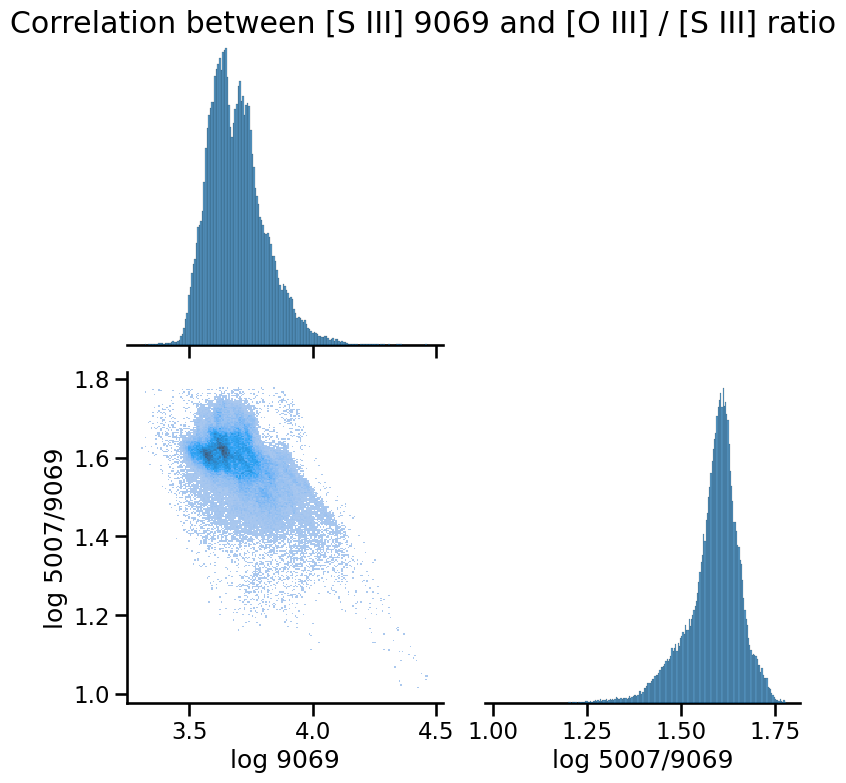

In [39]:
slope = 45
slope2 = 35
x = im9069cc.data
y = im5007cc.data
m = x > imin
m = m & (y > 10 * x) & (y < 60 * x)
m = m & ~im9069cc.mask & ~im5007cc.mask
df = pd.DataFrame(
    {
        "log 9069": np.log10(x[m]),
        "log 5007/9069": np.log10(y[m] / x[m]),
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.fig.suptitle("Correlation between [S III] 9069 and [O III] / [S III] ratio")

In [40]:
imR_oiii_siii = (im5007cc) / im9069cc
imR_oiii_siii.write(
    str(ROOT / "data/ngc346-ZZ-R-oiii-5007-siii-9069.fits"), savemask="nan"
)

In [41]:
im5007cc.write(
    str(ROOT / "data/ngc346-ZZ-oiii-5007-correct.fits"), savemask="nan"
)
im9069cc.write(
    str(ROOT / "data/ngc346-ZZ-siii-9069-correct.fits"), savemask="nan"
)

## Calculate [O III] / Hβ

This might be better since at least it is not affected by reddening.

In [42]:
imhb = get_image_raw("h-i-4861-32")

Text(0.5, 0.98, 'Correlation between Hβ 4861 and [O III] 5007 brightness')

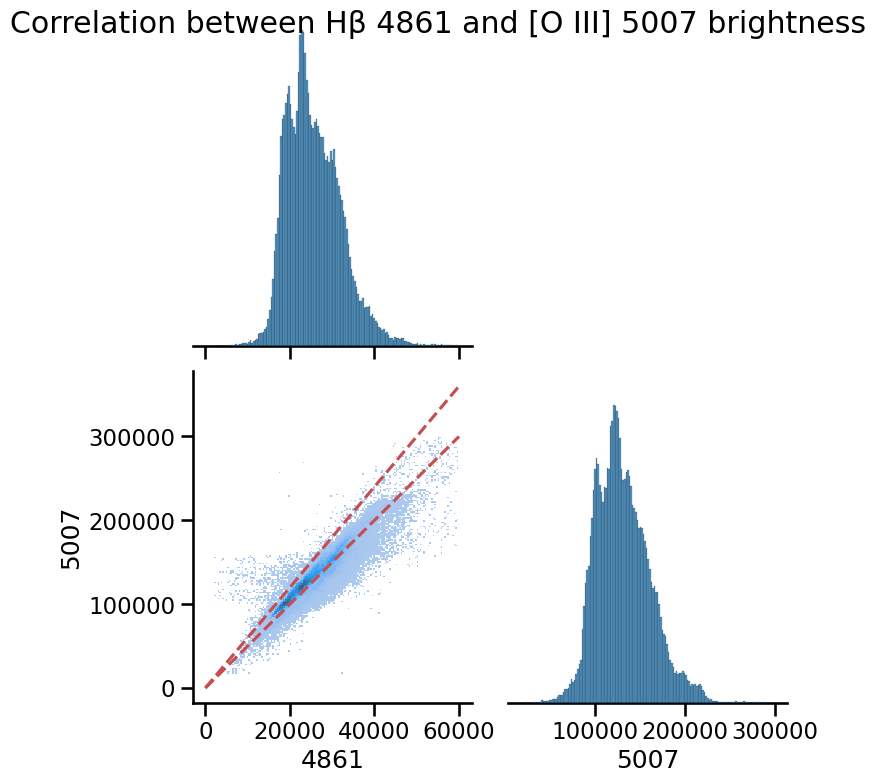

In [43]:
imax = 60000
imin = 2000
slope = 5.0
slope2 = 6.0
x = imhb.data
y = im5007.data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > slope * imin)
m = m & ~imhb.mask & ~im5007.mask
df = pd.DataFrame(
    {
        "4861": x[m],
        "5007": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.axes[1, 0].plot([0, imax], [0, slope2 * imax], "--", color="r")
g.fig.suptitle("Correlation between Hβ 4861 and [O III] 5007 brightness")

Text(0.5, 0.98, 'Correlation between Hβ 4861 and [O III] / Hβ ratio')

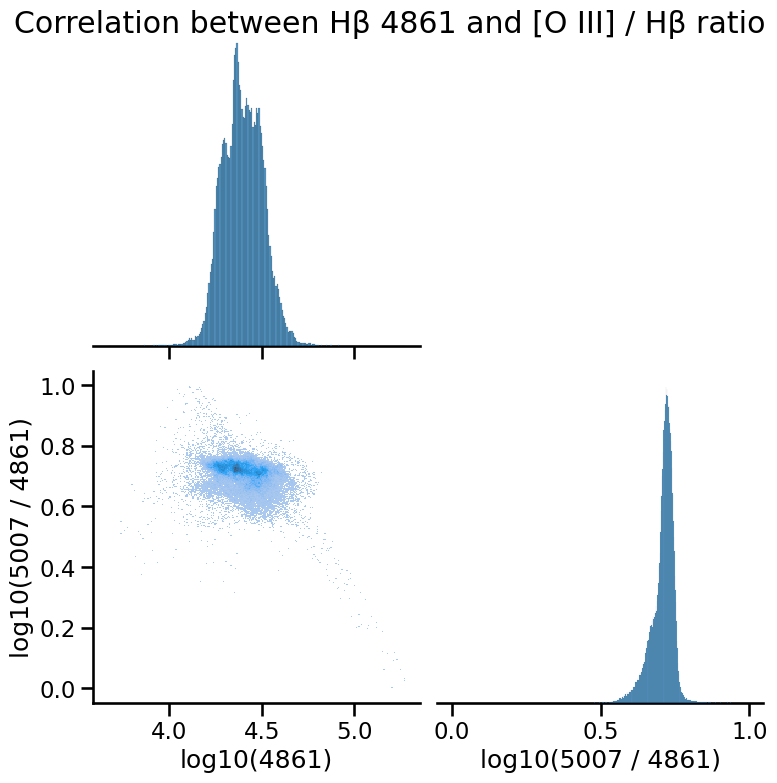

In [44]:
n = 1
x = imhb.rebin(n).data
y = im5007.rebin(n).data
m = (x > imin) & (y > x) & (y < 10 * x)
m = m & ~imhb.rebin(n).mask & ~im5007.rebin(n).mask
df = pd.DataFrame(
    {
        "log10(4861)": np.log10(x[m]),
        "log10(5007 / 4861)": np.log10(y[m] / x[m]),
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.fig.suptitle("Correlation between Hβ 4861 and [O III] / Hβ ratio")

In [45]:
imR_oiii_hb = (im5007) / (imhb)
imR_oiii_hb.write(str(ROOT / "data/ngc346-ZZ-R-oiii-5007-hi-4861.fits"), savemask="nan")

In [46]:
im4740 = get_image_raw("ar-iv-4740-17")

In [47]:
from astropy.convolution import convolve_fft
from astropy.convolution import Gaussian2DKernel

In [48]:
im = convolve_fft(im4740.data, Gaussian2DKernel(5.0))

Text(0.5, 1.0, '[O III] / Hβ')

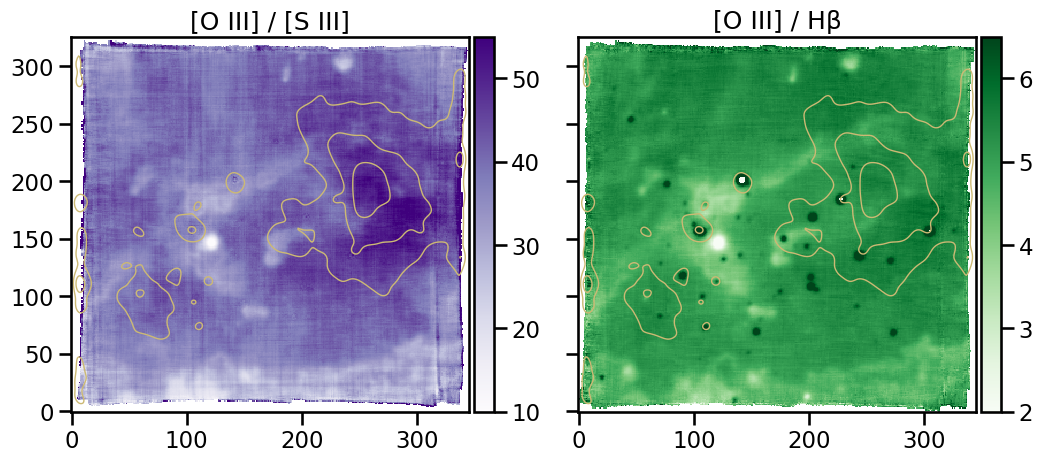

In [49]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
imR_oiii_siii.plot(
    vmin=10,
    vmax=55,
    colorbar="v",
    scale="linear",
    ax=axes[0],
    cmap="Purples",
)
imR_oiii_hb.plot(
    vmin=2,
    vmax=6.5,
    colorbar="v",
    scale="linear",
    ax=axes[1],
    cmap="Greens",
)
for ax in axes:
    ax.contour(im, levels=[100, 150, 200], linewidths=1, colors="y")
axes[0].set_title("[O III] / [S III]")
axes[1].set_title("[O III] / Hβ")

So, the bow shock shows up much better in [O III]/[S III] than it does in [O III]/Hb.  This implies that it must be a lack of [S III], rather than an excess of [O III] that characterises the bow shock.